In [93]:
import nltk
nltk.download('universal_tagset')

[nltk_data] Downloading package universal_tagset to
[nltk_data]     C:\Users\naveen\AppData\Roaming\nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


True

In [94]:
from nltk.corpus import brown
# Get the tagged sentences from the Brown corpus using the universal tagset
tagged_sentences = list(brown.tagged_sents(tagset='universal'))

In [95]:
# Shuffle the sentences to ensure randomness and then split into training, test and validation sets
import random
tagged_sentences = list(tagged_sentences)
random.shuffle(tagged_sentences)

# compute boundaries so that the splits are 80%, 10% and 10%
n = len(tagged_sentences)
train_end = int(0.8 * n)
test_end = train_end + int(0.1 * n)

train_data = tagged_sentences[:train_end]
test_data = tagged_sentences[train_end:test_end]
validation_data = tagged_sentences[test_end:]

# sanity check
print(len(train_data), len(test_data), len(validation_data))

45872 5734 5734


In [96]:
# Section 3 Boilerplate: POS tagging with MLP (SVD / Word2Vec2 / GloVe)
# This notebook scaffold is intentionally modular so you can learn each part.

from pathlib import Path
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score, confusion_matrix
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [97]:
# Configuration
PROJECT_ROOT = Path.cwd()
EMBED_DIR = PROJECT_ROOT / "embeddings"

CONFIG = {
    "context_size": 1,                # C in the assignment (window = 2C+1)
    "batch_size": 256,
    "epochs": 8,
    "learning_rate": 1e-3,
    "dropout": 0.2,
    "hidden_dims": [256, 128],        # at least two hidden layers
    "freeze_embeddings": True,
    "svd_path": EMBED_DIR / "svd.pt",
    "word2vec2_path": EMBED_DIR / "word2vec2.pt",
    "glove_name": "glove-wiki-gigaword-100",  # gensim downloader name (no local file path needed)
}

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

print(CONFIG)

{'context_size': 1, 'batch_size': 256, 'epochs': 8, 'learning_rate': 0.001, 'dropout': 0.2, 'hidden_dims': [256, 128], 'freeze_embeddings': True, 'svd_path': WindowsPath('c:/Users/naveen/Desktop/INLP/Assign2/embeddings/svd.pt'), 'word2vec2_path': WindowsPath('c:/Users/naveen/Desktop/INLP/Assign2/embeddings/word2vec2.pt'), 'glove_name': 'glove-wiki-gigaword-100'}


In [98]:
# Embedding loaders and lookup helpers

def normalize_token(token: str) -> str:
    return token.lower()


def load_svd_payload(path: Path):
    payload = torch.load(path, map_location="cpu", weights_only=False)
    matrix = payload["embeddings"]
    if isinstance(matrix, torch.Tensor):
        matrix = matrix.detach().cpu().numpy()
    matrix = np.asarray(matrix, dtype=np.float32)
    vocab_index = payload["vocab_index"]
    return vocab_index, matrix


def load_word2vec_payload(path: Path):
    payload = torch.load(path, map_location="cpu", weights_only=False)
    matrix = payload["embeddings"]
    if isinstance(matrix, torch.Tensor):
        matrix = matrix.detach().cpu().numpy()
    matrix = np.asarray(matrix, dtype=np.float32)
    vocab_index = payload["vocab_index"]
    return vocab_index, matrix


def load_glove_from_gensim(glove_name: str):
    try:
        import importlib
        api = importlib.import_module("gensim.downloader")
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "gensim is required for pretrained GloVe. Install with: pip install gensim"
        ) from exc

    print(f"Loading pretrained embeddings: {glove_name}")
    kv = api.load(glove_name)

    vocab_index = dict(kv.key_to_index)
    matrix = np.asarray(kv.vectors, dtype=np.float32)
    return vocab_index, matrix


def build_lookup(vocab_index: dict, matrix: np.ndarray):
    embedding_dim = int(matrix.shape[1])
    lookup = {token: matrix[idx] for token, idx in vocab_index.items()}

    lookup[PAD_TOKEN] = np.zeros(embedding_dim, dtype=np.float32)
    lookup[UNK_TOKEN] = np.zeros(embedding_dim, dtype=np.float32)
    return lookup, embedding_dim


def get_vec(token: str, lookup: dict):
    if token in lookup:
        return lookup[token]
    token_lower = normalize_token(token)
    if token_lower in lookup:
        return lookup[token_lower]
    return lookup[UNK_TOKEN]

In [99]:
def load_embedding_variant(name: str, cfg: dict):
    name = name.lower()
    if name == "svd":
        vocab_index, matrix = load_svd_payload(Path(cfg["svd_path"]))
    elif name == "word2vec2":
        vocab_index, matrix = load_word2vec_payload(Path(cfg["word2vec2_path"]))
    elif name == "glove":
        vocab_index, matrix = load_glove_from_gensim(cfg["glove_name"])
    else:
        raise ValueError("Unknown embedding variant. Use: svd, word2vec2, glove")

    lookup, embedding_dim = build_lookup(vocab_index, matrix)
    return lookup, embedding_dim

In [100]:
# POS tags and sliding-window dataset builder

def build_tag_vocab(train_sentences):
    tags = sorted({tag for sentence in train_sentences for _, tag in sentence})
    tag2id = {tag: idx for idx, tag in enumerate(tags)}
    id2tag = {idx: tag for tag, idx in tag2id.items()}
    return tag2id, id2tag


def sentence_to_examples(tagged_sentence, lookup, tag2id, context_size: int):
    tokens = [w for (w, _) in tagged_sentence]
    tags = [t for (_, t) in tagged_sentence]

    features = []
    labels = []

    for center in range(len(tokens)):
        window_vecs = []
        for offset in range(-context_size, context_size + 1):
            pos = center + offset
            if pos < 0 or pos >= len(tokens):
                tok = PAD_TOKEN
            else:
                tok = tokens[pos]
            window_vecs.append(get_vec(tok, lookup))

        features.append(np.concatenate(window_vecs, axis=0))
        labels.append(tag2id[tags[center]])

    return features, labels


def split_to_xy(tagged_sentences_split, lookup, tag2id, context_size: int):
    all_x, all_y = [], []
    for sentence in tagged_sentences_split:
        x_sent, y_sent = sentence_to_examples(sentence, lookup, tag2id, context_size)
        all_x.extend(x_sent)
        all_y.extend(y_sent)

    X = np.asarray(all_x, dtype=np.float32)
    y = np.asarray(all_y, dtype=np.int64)
    return X, y


tag2id, id2tag = build_tag_vocab(train_data)
print(f"Number of POS tags: {len(tag2id)}")
print("Tag set:", sorted(tag2id.keys()))

Number of POS tags: 12
Tag set: ['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']


In [101]:
# MLP model (two hidden layers minimum)
class MLPPOSTagger(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], num_tags: int, dropout: float = 0.2):
        super().__init__()
        h1, h2 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, num_tags),
        )

    def forward(self, x):
        return self.net(x)

In [102]:
# Training and evaluation helpers

def make_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size: int):
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def run_epoch(model, loader, criterion, optimizer=None, show_progress: bool = False, progress_desc: str = ""):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    iterator = loader
    if show_progress:
        iterator = tqdm(loader, desc=progress_desc, leave=False)

    with torch.set_grad_enabled(training):
        for xb, yb in iterator:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(yb.detach().cpu().numpy().tolist())

            if show_progress:
                iterator.set_postfix(loss=f"{loss.item():.4f}")

    n = len(all_labels)
    avg_loss = total_loss / max(n, 1)
    accuracy = float((np.array(all_preds) == np.array(all_labels)).mean()) if n else 0.0
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0) if n else 0.0

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "preds": np.array(all_preds, dtype=np.int64),
        "labels": np.array(all_labels, dtype=np.int64),
    }


def train_model(model, train_loader, val_loader, cfg):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["learning_rate"])

    history = []
    best_val_acc = -float("inf")
    best_epoch = 0
    best_state_dict = copy.deepcopy(model.state_dict())

    for epoch in range(1, cfg["epochs"] + 1):
        train_stats = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            show_progress=True,
            progress_desc=f"Epoch {epoch:02d} [train]",
        )
        val_stats = run_epoch(model, val_loader, criterion, optimizer=None)

        row = {
            "epoch": epoch,
            "train_loss": train_stats["loss"],
            "train_acc": train_stats["accuracy"],
            "train_macro_f1": train_stats["macro_f1"],
            "val_loss": val_stats["loss"],
            "val_acc": val_stats["accuracy"],
            "val_macro_f1": val_stats["macro_f1"],
        }
        history.append(row)

        if val_stats["accuracy"] > best_val_acc:
            best_val_acc = val_stats["accuracy"]
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={row['train_loss']:.4f}, train_acc={row['train_acc']:.4f}, "
            f"val_loss={row['val_loss']:.4f}, val_acc={row['val_acc']:.4f}, "
            f"val_macro_f1={row['val_macro_f1']:.4f}"
        )

    history_df = pd.DataFrame(history)
    return history_df, best_state_dict, best_epoch, best_val_acc

In [103]:
# Experiment runner for one embedding variant

def run_experiment(embedding_name: str, cfg: dict):
    print(f"\n===== Running variant: {embedding_name} =====")
    lookup, embedding_dim = load_embedding_variant(embedding_name, cfg)

    context_size = cfg["context_size"]
    X_train, y_train = split_to_xy(train_data, lookup, tag2id, context_size)
    X_val, y_val = split_to_xy(validation_data, lookup, tag2id, context_size)
    X_test, y_test = split_to_xy(test_data, lookup, tag2id, context_size)

    input_dim = (2 * context_size + 1) * embedding_dim
    num_tags = len(tag2id)

    print("Input shapes:", X_train.shape, X_val.shape, X_test.shape)
    print(f"MLP input_dim={input_dim}, num_tags={num_tags}")

    train_loader, val_loader, test_loader = make_dataloaders(
        X_train, y_train, X_val, y_val, X_test, y_test, cfg["batch_size"]
    )

    model = MLPPOSTagger(
        input_dim=input_dim,
        hidden_dims=cfg["hidden_dims"],
        num_tags=num_tags,
        dropout=cfg["dropout"],
    ).to(device)

    history_df, best_state_dict, best_epoch, best_val_acc = train_model(model, train_loader, val_loader, cfg)

    model.load_state_dict(best_state_dict)
    print(f"Selected best checkpoint -> epoch={best_epoch:02d}, val_acc={best_val_acc:.4f}")

    criterion = nn.CrossEntropyLoss()
    test_stats = run_epoch(model, test_loader, criterion, optimizer=None)

    cm = confusion_matrix(test_stats["labels"], test_stats["preds"], labels=list(range(num_tags)))
    cm_df = pd.DataFrame(cm, index=[id2tag[i] for i in range(num_tags)], columns=[id2tag[i] for i in range(num_tags)])

    summary = {
        "embedding": embedding_name,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "test_accuracy": test_stats["accuracy"],
        "test_macro_f1": test_stats["macro_f1"],
    }

    print(
        f"Test results ({embedding_name}) -> "
        f"accuracy={summary['test_accuracy']:.4f}, macro_f1={summary['test_macro_f1']:.4f}"
    )

    return {
        "model": model,
        "history": history_df,
        "summary": summary,
        "confusion_matrix": cm_df,
    }

In [104]:
# Run all three embedding variants
VARIANTS = ["svd", "word2vec2", "glove"]

results = {}
comparison_rows = []

for variant in VARIANTS:
    try:
        out = run_experiment(variant, CONFIG)
        results[variant] = out
        comparison_rows.append(out["summary"])
    except (FileNotFoundError, ModuleNotFoundError) as error:
        print(f"Skipping {variant}: {error}")

if comparison_rows:
    comparison_df = pd.DataFrame(comparison_rows)
    comparison_df = comparison_df.sort_values(by="test_macro_f1", ascending=False).reset_index(drop=True)
    print("\n=== Final Comparison (higher is better) ===")
    print(comparison_df.to_string(index=False))
else:
    print("No experiments ran successfully.")


===== Running variant: svd =====
Input shapes: (929015, 90) (115827, 90) (116350, 90)
MLP input_dim=90, num_tags=12


Epoch 01 | train_loss=0.3083, train_acc=0.9014, val_loss=0.1693, val_acc=0.9435, val_macro_f1=0.8579


Epoch 02 | train_loss=0.1812, train_acc=0.9401, val_loss=0.1473, val_acc=0.9500, val_macro_f1=0.8757


Epoch 03 | train_loss=0.1642, train_acc=0.9454, val_loss=0.1385, val_acc=0.9531, val_macro_f1=0.8823


Epoch 04 | train_loss=0.1550, train_acc=0.9480, val_loss=0.1337, val_acc=0.9543, val_macro_f1=0.8872


...

Epoch 04 | train_loss=0.0971, train_acc=0.9683, val_loss=0.0801, val_acc=0.9738, val_macro_f1=0.9394


Epoch 05 | train_loss=0.0923, train_acc=0.9697, val_loss=0.0788, val_acc=0.9744, val_macro_f1=0.9350


Epoch 06 | train_loss=0.0882, train_acc=0.9708, val_loss=0.0748, val_acc=0.9756, val_macro_f1=0.9423


Epoch 07 | train_loss=0.0850, train_acc=0.9718, val_loss=0.0752, val_acc=0.9759, val_macro_f1=0.9425


Epoch 08 | train_loss=0.0822, train_acc=0.9726, val_loss=0.0746, val_acc=0.9758, val_macro_f1=0.9422
Selected best checkpoint -> epoch=07, val_acc=0.9759
Test results (glove) -> accuracy=0.9757, macro_f1=0.9477

=== Final Comparison (higher is better) ===
embedding  best_epoch  best_val_acc  test_accuracy  test_macro_f1
    glove           7      0.975878       0.975677       0.947693
word2vec2           8      0.965682       0.966154       0.914193
      svd           8      0.958593       0.958711       0.892573



=== Confusion Matrix: svd ===
          .   ADJ    ADP   ADV  CONJ    DET   NOUN   NUM  PRON   PRT   VERB   X
.     14905     0      0     0     0      0      2     0     0     0      0   0
ADJ       0  7139      5   126     0      1    829     7     0     1    194   0
ADP      10    12  14363    49    12     16     10     0    20   101     21   0
ADV       0   201     89  5041    11     20    201     1     1    24     96   0
CONJ      0     1      0     8  3768      1      1     0     0     0      1   0
DET       0     0     43     3     4  13600      3     0    39     1      2   0
NOUN      0   529      2    62     1      6  26550    47     2     5    389   8
NUM       0    15      0     1     0      0    164  1237     0     0     21   0
PRON      0     3     25     0     0     33      7     0  4908     0      0   0
PRT       0     2    132     9     0      0     21     0     0  2772      9   0
VERB      0   247      6    21     0      0    766     4     0     4  17248   1
X        

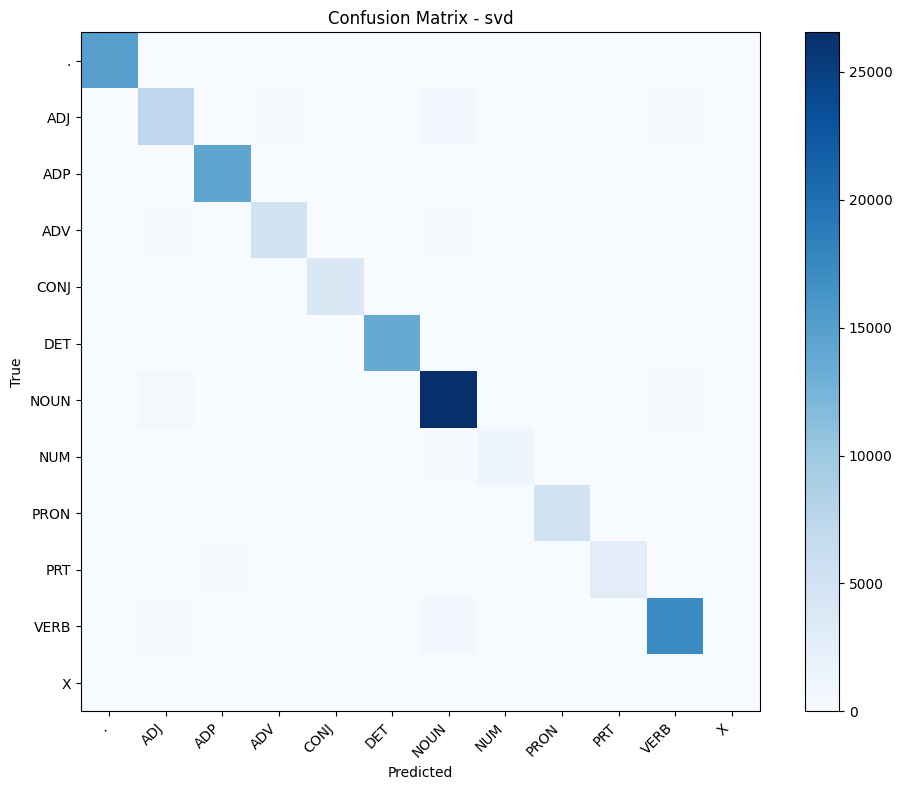


=== Confusion Matrix: word2vec2 ===
          .   ADJ    ADP   ADV  CONJ    DET   NOUN   NUM  PRON   PRT   VERB   X
.     14905     0      0     0     0      0      2     0     0     0      0   0
ADJ       0  7401      4   119     0      0    647     2     0     2    127   0
ADP       7     5  14429    53     6     32      7     0     9    58      8   0
ADV       0   149     71  5225     7     18    137     1     1    27     49   0
CONJ      0     0     13     4  3761      2      0     0     0     0      0   0
DET       0     0     21     6     5  13627      3     0    32     1      0   0
NOUN      0   468      3    30     1     12  26720    32     3    10    310  12
NUM       0    10      0     0     0      0    158  1257     0     1     12   0
PRON      0     0     24     0     0     38      2     0  4912     0      0   0
PRT       0     1    136     7     0      0     20     0     0  2778      3   0
VERB      0   227      7    22     1      0    660     7     0     5  17367   1
X  

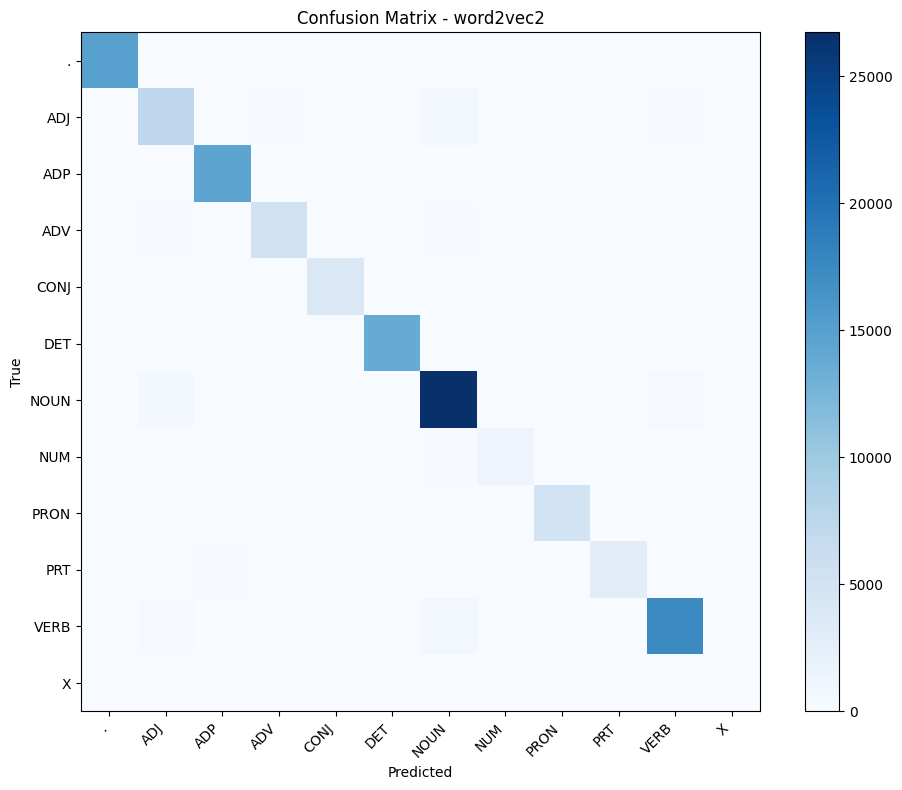


=== Confusion Matrix: glove ===
          .   ADJ    ADP   ADV  CONJ    DET   NOUN   NUM  PRON   PRT   VERB   X
.     14906     0      0     0     0      0      0     0     0     0      1   0
ADJ       0  7654      4    91     0      0    473     1     0     3     76   0
ADP       6     1  14419    61     5     34      1     1    11    68      7   0
ADV       0   178    106  5257    12     21     53     0     0    27     31   0
CONJ      0     0      3     4  3762      9      0     0     0     0      2   0
DET       0     0     34     6     2  13632      3     0    16     2      0   0
NOUN      0   218      4    12     1      8  27006    29     2    34    274  13
NUM       0     1      0     0     0      0     32  1405     0     0      0   0
PRON      0     0     21     0     0     54      1     0  4899     1      0   0
PRT       0     0    132     4     0      0     58     0     1  2741      9   0
VERB      0    96      8    21     0      0    348     0     1    46  17774   3
X      

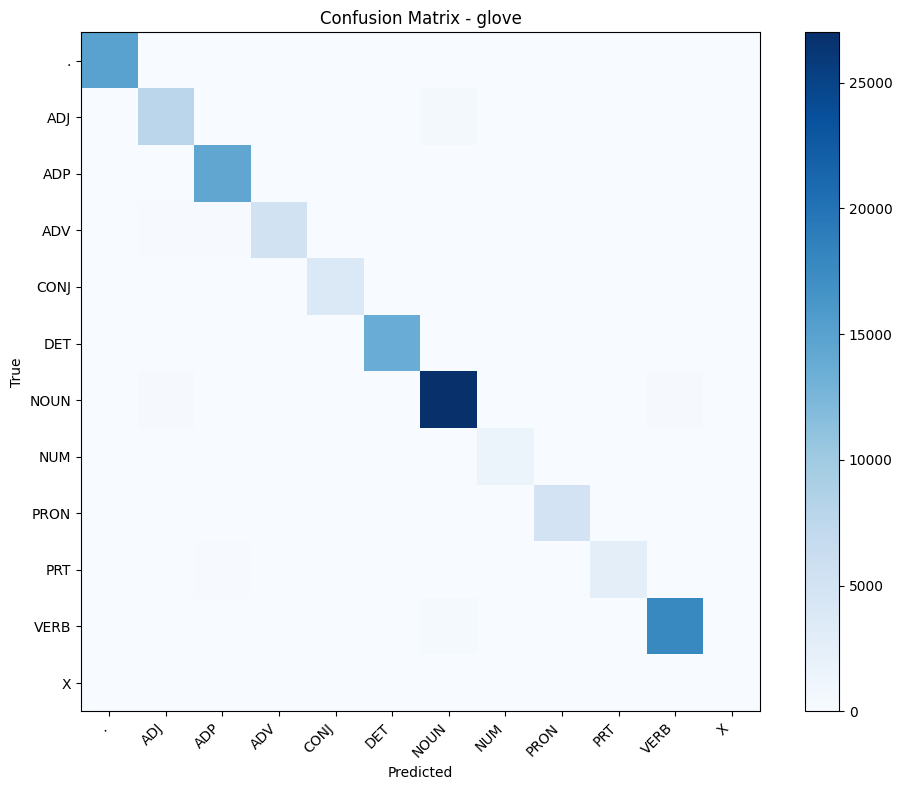

In [105]:
# Inspect confusion matrix for a chosen variant after running experiments
for variant_to_view in ['svd', 'word2vec2', 'glove']:
    # variant_to_view = "svd"  # change to 'word2vec2' or 'glove'

    if variant_to_view in results:
        cm_df = results[variant_to_view]["confusion_matrix"]

        print(f"\n=== Confusion Matrix: {variant_to_view} ===")
        print(cm_df.to_string())

        try:
            import matplotlib.pyplot as plt

            fig, ax = plt.subplots(figsize=(10, 8))
            im = ax.imshow(cm_df.values, cmap="Blues")
            ax.set_title(f"Confusion Matrix - {variant_to_view}")
            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")
            ax.set_xticks(range(len(cm_df.columns)))
            ax.set_xticklabels(cm_df.columns, rotation=45, ha="right")
            ax.set_yticks(range(len(cm_df.index)))
            ax.set_yticklabels(cm_df.index)
            fig.colorbar(im, ax=ax)
            plt.tight_layout()
            plt.show()
        except ModuleNotFoundError:
            print("matplotlib is not installed; showing table only.")
    else:
        print(f"No results found for {variant_to_view}. Did it run successfully?")